# 04. Normalization Test

This notebook checks coordinate normalization using a single comparison view.

Current method:

- translation reference: frame-wise hip center
- scale reference: sequence-wise median torso length

This notebook assumes that the previous checks are already working:

- 00_environment_check
- 01_data_loading_test
- 02_validation_test
- 03_raw_visualization_test

The goal here is to run normalization, check the normalization report, and compare raw and normalized coordinates in one visualization.


In [1]:
import json

from movement.io import load_pose_csv
from movement.config import LANDMARKS, CONNECTIONS
from movement.normalization import (
    normalize_pose_by_hip_torso,
    check_normalization_result,
)
from movement.visualization import create_pose_comparison_animation


In [2]:
csv_path = "../data/pose/sample/mediapipe_squat_synthetic.csv"

df = load_pose_csv(csv_path)

df.head()


,frame,timestamp,nose_x,nose_y,nose_z,nose_visibility,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_inner_visibility,...,right_heel_z,right_heel_visibility,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_visibility,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_visibility
0,0,0.0000,0.50152,0.18137,0.01269,0.9413,0.48808,0.17023,0.01057,0.9551,...,0.01897,0.9653,0.46124,0.94928,-0.01786,0.9792,0.53815,0.95001,-0.02009,0.9733
1,1,0.0333,0.50199,0.17853,0.00879,0.9640,0.49088,0.16868,0.01160,0.9521,...,0.02011,0.9819,0.46109,0.95189,-0.02398,0.9631,0.53907,0.94967,-0.02031,0.9410
2,2,0.0667,0.50148,0.17711,0.01098,0.9622,0.48783,0.17292,0.00888,0.9433,...,0.02149,0.9407,0.46135,0.95170,-0.01824,0.9400,0.54266,0.94755,-0.02123,0.9788
3,3,0.1000,0.50035,0.17977,0.01165,0.9540,0.48961,0.17090,0.00813,0.9625,...,0.02151,0.9709,0.45963,0.95245,-0.02044,0.9544,0.54109,0.95160,-0.01748,0.9668
4,4,0.1333,0.50187,0.17879,0.00940,0.9770,0.49074,0.17317,0.00872,0.9523,...,0.02150,0.9899,0.45915,0.95058,-0.01850,0.9699,0.53820,0.95276,-0.02147,0.9584


In [3]:
norm_df, norm_report = normalize_pose_by_hip_torso(
    df=df,
    landmarks=LANDMARKS,
)

print(json.dumps(norm_report, indent=2, ensure_ascii=False))


{
  "method": "hip_centered_sequence_median_torso_scale",
  "num_frames": 120,
  "num_normalized_landmarks": 33,
  "normalized_columns": [
    "nose_norm_x",
    "nose_norm_y",
    "nose_norm_z",
    "left_eye_inner_norm_x",
    "left_eye_inner_norm_y",
    "left_eye_inner_norm_z",
    "left_eye_norm_x",
    "left_eye_norm_y",
    "left_eye_norm_z",
    "left_eye_outer_norm_x",
    "left_eye_outer_norm_y",
    "left_eye_outer_norm_z",
    "right_eye_inner_norm_x",
    "right_eye_inner_norm_y",
    "right_eye_inner_norm_z",
    "right_eye_norm_x",
    "right_eye_norm_y",
    "right_eye_norm_z",
    "right_eye_outer_norm_x",
    "right_eye_outer_norm_y",
    "right_eye_outer_norm_z",
    "left_ear_norm_x",
    "left_ear_norm_y",
    "left_ear_norm_z",
    "right_ear_norm_x",
    "right_ear_norm_y",
    "right_ear_norm_z",
    "mouth_left_norm_x",
    "mouth_left_norm_y",
    "mouth_left_norm_z",
    "mouth_right_norm_x",
    "mouth_right_norm_y",
    "mouth_right_norm_z",
    "left_shoul

In [4]:
check_report = check_normalization_result(norm_df)

print(json.dumps(check_report, indent=2, ensure_ascii=False))


{
  "passed": true,
  "max_abs_hip_center": 2.498001805406602e-16,
  "median_normalized_torso_length": 1.0,
  "min_normalized_torso_length": 0.9681634801452889,
  "max_normalized_torso_length": 1.080763028524061
}


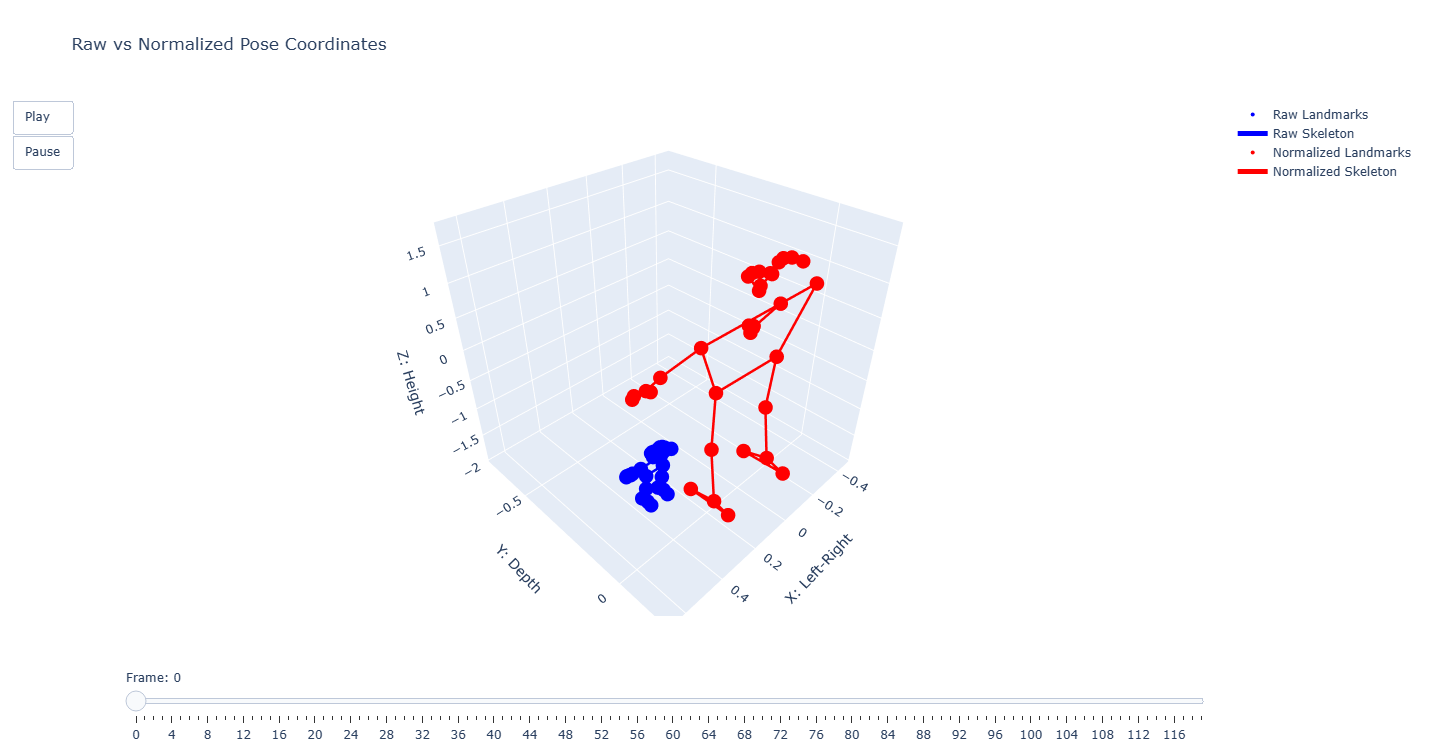

In [5]:
fig_compare = create_pose_comparison_animation(
    df=norm_df,
    landmarks=LANDMARKS,
    connections=CONNECTIONS,
    coord_modes=("raw", "norm"),
    names=("Raw", "Normalized"),
    title="Raw vs Normalized Pose Coordinates",
    show_text=False,
)

fig_compare.show()


## Interpretation

The raw and normalized skeletons may appear in different positions because they use different coordinate systems.

- Raw coordinates use the original pose/model coordinate space.
- Normalized coordinates use a hip-centered and torso-scaled coordinate space.

The comparison view is mainly for debugging whether both coordinate modes are available and whether the normalized skeleton behaves consistently.

Expected checks:

- `check_report["passed"]` should be `True`
- normalized hip center should be approximately zero
- median normalized torso length should be approximately 1.0
